In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
import os
from dotenv import load_dotenv,find_dotenv

load_dotenv(find_dotenv(),override=True)
# assert os.getenv("MODEL"),"模型GG"
# MODEL = os.getenv("MODEL")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_API_BASE = os.getenv("GROQ_API_BASE")
GROQ_API_MODEL = os.getenv("GROQ_API_MODEL")

assert GROQ_API_KEY, "没有读取到 GROQ_API_KEY"
assert GROQ_API_BASE, "没有读取到 GROQ_API_BASE"
assert GROQ_API_MODEL, "没有读取到 GROQ_API_MODEL"

print("环境变量读取成功")

环境变量读取成功


In [3]:
%matplotlib qt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RangeSlider,TextBox  # 引入范围滑动条组件
from scipy.signal import convolve2d
import scipy.io as sio

In [4]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from langchain_core.messages import HumanMessage, SystemMessage

from IPython.display import Image, display

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

from assets.cnn.Unet import Unet
from assets.bnn.bunetPP import UNetPlusPlus

In [5]:
# =========================
# 2. 全局结果缓存
#    结构:
# global_strain_results = {
#     "D:/.../phase2.mat": {
#         "vector|g=1|Nx=25|Nz=25|bandwidth=5e-08|Lambda=8.4e-07|n=1.0": ...,
#         "vector|g=3|Nx=25|Nz=25|bandwidth=5e-08|Lambda=8.4e-07|n=1.0": ...,
#         "cnn": ...
#     }
# }
# =========================
global_strain_results = {}



# CNN 模型缓存
global_cnn_model = None
global_cnn_model_path = None
global_cnn_model_device = None

DEFAULT_CNN_MODEL_PATH = os.path.join("assets", "cnn", "model.pth")

global_bnn_model = None
global_bnn_model_path = None
global_bnn_model_device = None

DEFAULT_BNN_MODEL_PATH = os.path.join("assets", "bnn", "model.pth")

def crop_to_divisible_by_32(un_phase: np.ndarray) -> np.ndarray:
    """
    将输入二维矩阵裁剪成行列都能被32整除的最大尺寸。
    """
    target_rows = un_phase.shape[0] - (un_phase.shape[0] % 32)
    target_cols = un_phase.shape[1] - (un_phase.shape[1] % 32)

    rows_to_crop = un_phase.shape[0] - target_rows
    cols_to_crop = un_phase.shape[1] - target_cols

    top_crop = rows_to_crop // 2
    bottom_crop = rows_to_crop - top_crop
    left_crop = cols_to_crop // 2
    right_crop = cols_to_crop - left_crop

    if bottom_crop == 0:
        cropped_phase = un_phase[top_crop:, :]
    else:
        cropped_phase = un_phase[top_crop:-bottom_crop, :]

    if right_crop == 0:
        cropped_phase = cropped_phase[:, left_crop:]
    else:
        cropped_phase = cropped_phase[:, left_crop:-right_crop]

    return cropped_phase

def save_result(file_path: str, result_key: str, result_obj):
    global global_strain_results
    if file_path not in global_strain_results:
        global_strain_results[file_path] = {}
    global_strain_results[file_path][result_key] = result_obj


def load_cnn_model(device: torch.device, model_path: str = DEFAULT_CNN_MODEL_PATH):
    global global_cnn_model, global_cnn_model_path, global_cnn_model_device

    device_str = str(device)

    if (
        global_cnn_model is not None
        and global_cnn_model_path == model_path
        and global_cnn_model_device == device_str
    ):
        return global_cnn_model

    net = Unet()
    net.load_state_dict(torch.load(model_path, map_location=device))
    net.to(device)
    net.eval()

    global_cnn_model = net
    global_cnn_model_path = model_path
    global_cnn_model_device = device_str
    return net

def load_bnn_model(device: torch.device, model_path: str = DEFAULT_BNN_MODEL_PATH):
    global global_bnn_model, global_bnn_model_path, global_bnn_model_device

    device_str = str(device)

    if (
        global_bnn_model is not None
        and global_bnn_model_path == model_path
        and global_bnn_model_device == device_str
    ):
        return global_bnn_model

    net = UNetPlusPlus()
    net.load_state_dict(torch.load(model_path, map_location=device))
    net.to(device)
    net.eval()

    global_bnn_model = net
    global_bnn_model_path = model_path
    global_bnn_model_device = device_str
    return net

def make_vector_result_key(
    Nx: int,
    Nz: int,
    g: int,
    bandwidth: float,
    Lambda: float,
    n: float,
) -> str:
    return f"vector_g={g}_Nx={Nx}_Nz={Nz}"


def make_cnn_result_key() -> str:
    return "cnn"

def make_bnn_result_key(MC_test: int) -> str:
    return f"bnn|MC_test={MC_test}"

In [6]:
# =========================
# 3. 可视化函数
# =========================
def visualize_matrix_interactive(
    data,
    title="Interactive Visualization",
    cmap="jet",
    init_range=(-1.0, 1.0),
):
    fig, ax = plt.subplots(figsize=(9, 7))
    plt.subplots_adjust(bottom=0.3)

    d_min, d_max = np.nanmin(data), np.nanmax(data)
    vmin, vmax = init_range

    if vmin >= vmax or vmin < d_min or vmax > d_max:
        vmin, vmax = d_min, d_max

    img = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title)
    fig.colorbar(img, ax=ax)

    slider_ax = fig.add_axes([0.2, 0.15, 0.6, 0.03])
    ax_box_min = fig.add_axes([0.2, 0.05, 0.15, 0.04])
    ax_box_max = fig.add_axes([0.65, 0.05, 0.15, 0.04])

    color_slider = RangeSlider(slider_ax, "Range", d_min, d_max, valinit=(vmin, vmax))
    text_min = TextBox(ax_box_min, "Min: ", initial=f"{vmin:.2f}")
    text_max = TextBox(ax_box_max, "Max: ", initial=f"{vmax:.2f}")

    def update_display(new_vmin, new_vmax):
        img.set_clim(new_vmin, new_vmax)
        fig.canvas.draw_idle()

    color_slider.on_changed(lambda val: update_display(val[0], val[1]))

    def on_text_submit(_):
        try:
            new_vmin = float(text_min.text)
            new_vmax = float(text_max.text)
            if new_vmin < new_vmax:
                color_slider.set_val((new_vmin, new_vmax))
                update_display(new_vmin, new_vmax)
        except ValueError:
            pass

    text_min.on_submit(on_text_submit)
    text_max.on_submit(on_text_submit)

    fig.interacts = [color_slider, text_min, text_max]
    plt.show(block=False)

# tool

In [7]:


# =========================
# 4. 工具：矢量法
# =========================
@tool
def vector_method_g(
    file_path: str,
    Nx: int = 25,
    Nz: int = 25,
    g: int = 1,
    bandwidth: float = 50e-9,
    Lambda: float = 840e-9,
    n: float = 1.0,
):
    """
    矢量法应变计算工具。
    当用户要求使用矢量法进行应变计算时调用。

    参数:
        file_path: 待处理的 .mat 相位文件绝对路径。
        Nx: 横向窗口大小。
        Nz: 轴向（纵向）窗口大小。
        g: 步长。
        bandwidth: 带宽 (m)。
        Lambda: 波长 (m)。
        n: 折射率。

    返回:
        执行状态说明。
    """
    try:
        result_key = make_vector_result_key(Nx, Nz, g, bandwidth, Lambda, n)

        # 重复保护：同一文件 + 同一组参数，不重复算
        if (
            file_path in global_strain_results
            and result_key in global_strain_results[file_path]
        ):
            old_result = global_strain_results[file_path][result_key]
            return f"矢量法结果已存在，file={file_path}，key={result_key}，shape={old_result.shape}"

        mat_data = sio.loadmat(file_path)
        var_names = [k for k in mat_data.keys() if not k.startswith("_")]
        if not var_names:
            return f"矢量法计算失败：文件 {file_path} 中没有可用变量。"

        Det_Phase = mat_data[var_names[0]]

        p1 = (Lambda ** 2) / bandwidth
        phase_data = np.array(Det_Phase, dtype=float)
        phase_data[phase_data == 0] = np.nan

        kernel_x = np.ones((1, Nx)) / Nx
        complex_phase = np.exp(1j * phase_data)
        B = convolve2d(complex_phase, kernel_x, mode="valid")
        B_model, B_angle = np.abs(B), np.angle(B)

        rows, cols = B_angle.shape
        valid_g = min(g, rows - 1)
        if valid_g < 1:
            return f"矢量法计算失败：文件 {file_path} 的数据行数不足。"

        phase_diff = B_angle[valid_g:, :] - B_angle[:-valid_g, :]
        C = B_model[:-valid_g, :] * B_model[valid_g:, :] * np.exp(1j * phase_diff)
        Cnorm_angle = np.angle(C) / valid_g

        kernel_z = np.ones((Nz, 1)) / Nz
        avg_phase = np.angle(convolve2d(np.exp(1j * Cnorm_angle), kernel_z, mode="valid"))

        Weiyi = Lambda * avg_phase / (4 * np.pi * n)
        strain = Weiyi * 1e3 / p1
        strain = np.nan_to_num(strain, nan=0.0)

        save_result(file_path, result_key, strain)

        return f"矢量法计算成功，file={file_path}，key={result_key}，shape={strain.shape}"

    except Exception as e:
        return f"矢量法计算过程中发生错误: {str(e)}"
 


In [8]:
# =========================
# 5. 工具：CNN
# =========================
@tool
def cnn_method(
    file_path: str,
    device_str: str = "cuda:0",
):
    """
    CNN应变计算工具。
    当用户要求使用“CNN方法”、“深度学习方法”、“Unet方法”进行应变计算时调用。

    参数:
        file_path: 待处理的 .mat 相位文件绝对路径。
        device_str: 推理设备，默认 cuda:0，不可用时自动退回 cpu。

    返回:
        执行状态说明。
    """
    try:
        result_key = make_cnn_result_key()

        if (
            file_path in global_strain_results
            and result_key in global_strain_results[file_path]
        ):
            old_result = global_strain_results[file_path][result_key]
            return f"CNN结果已存在，file={file_path}，key={result_key}，shape={old_result.shape}"

        if device_str.startswith("cuda") and torch.cuda.is_available():
            device = torch.device(device_str)
        else:
            device = torch.device("cpu")

        if not os.path.exists(DEFAULT_CNN_MODEL_PATH):
            return f"CNN计算过程中发生错误: 未找到模型文件 {DEFAULT_CNN_MODEL_PATH}"

        net = load_cnn_model(device, DEFAULT_CNN_MODEL_PATH)

        mat_data = sio.loadmat(file_path)
        var_names = [k for k in mat_data.keys() if not k.startswith("__")]
        if len(var_names) != 1:
            return f"CNN计算过程中发生错误: 文件 {file_path} 中变量数量不为1。"

        wrapped_data = mat_data[var_names[0]]

        image = np.transpose(wrapped_data)
        image = torch.from_numpy(
            image.reshape(1, 1, image.shape[0], image.shape[1])
        ).to(device=device, dtype=torch.float32)

        with torch.no_grad():
            strain = net(image)

        strain = strain.squeeze().cpu().detach().numpy()
        strain = np.transpose(np.array(strain))

        save_result(file_path, result_key, strain)

        return f"CNN计算成功，file={file_path}，key={result_key}，shape={strain.shape}"

    except Exception as e:
        return f"CNN计算过程中发生错误: {str(e)}"

In [9]:
@tool
def bnn_method(
    file_path: str,
    MC_test: int = 50,
    device_str: str = "cuda:0",
):
    """
    BNN应变计算工具。
    当用户要求使用“BNN方法”、“贝叶斯神经网络方法”、“深度学习BNN方法”进行应变计算时调用。

    参数:
        file_path: 待处理的 .mat 相位文件绝对路径。
        MC_test: Monte Carlo采样次数，默认50。
        device_str: 推理设备，默认 cuda:0，不可用时自动退回 cpu。

    返回:
        执行状态说明。
    """
    try:
        result_key = make_bnn_result_key(MC_test)

        if (
            file_path in global_strain_results
            and result_key in global_strain_results[file_path]
        ):
            old_result = global_strain_results[file_path][result_key]
            strain_shape = old_result["strain"].shape
            unc_shape = old_result["epistemic_uncertainty"].shape
            return (
                f"BNN结果已存在，file={file_path}，key={result_key}，"
                f"strain_shape={strain_shape}，uncertainty_shape={unc_shape}"
            )

        if device_str.startswith("cuda") and torch.cuda.is_available():
            device = torch.device(device_str)
        else:
            device = torch.device("cpu")

        if not os.path.exists(DEFAULT_BNN_MODEL_PATH):
            return f"BNN计算过程中发生错误: 未找到模型文件 {DEFAULT_BNN_MODEL_PATH}"

        net = load_bnn_model(device, DEFAULT_BNN_MODEL_PATH)

        mat_data = sio.loadmat(file_path)
        var_names = [k for k in mat_data.keys() if not k.startswith("__")]
        if len(var_names) != 1:
            return f"BNN计算过程中发生错误: 文件 {file_path} 中变量数量不为1。"

        wrapped_data = mat_data[var_names[0]]
        wrapped_data = crop_to_divisible_by_32(wrapped_data)

        image = np.transpose(wrapped_data)
        image = torch.from_numpy(
            image.reshape(1, 1, image.shape[0], image.shape[1])
        ).to(device=device, dtype=torch.float32)

        means = []
        log_vars = []

        with torch.no_grad():
            for _ in range(MC_test):
                mean, log_var, _ = net(image)
                means.append(mean)
                log_vars.append(log_var)

        means = torch.stack(means)
        log_vars = torch.stack(log_vars)

        # 应变：对 mean 求 MC 平均
        predicts = torch.mean(means, dim=0).squeeze()
        predicts = predicts.cpu().detach().numpy()
        strain = np.transpose(np.array(predicts))

        # 模型不确定度：epistemic uncertainty
        epistemic_uncertainty = torch.var(means, dim=0).squeeze()
        epistemic_uncertainty = epistemic_uncertainty.cpu().detach().numpy() ** 0.5
        epistemic_uncertainty = np.transpose(np.array(epistemic_uncertainty))

        result_obj = {
            "strain": strain,
            "epistemic_uncertainty": epistemic_uncertainty,
        }

        save_result(file_path, result_key, result_obj)

        return (
            f"BNN计算成功，file={file_path}，key={result_key}，"
            f"strain_shape={strain.shape}，"
            f"epistemic_uncertainty_shape={epistemic_uncertainty.shape}"
        )

    except Exception as e:
        return f"BNN计算过程中发生错误: {str(e)}"

In [10]:
# =========================
# 6. 模型
# =========================
tools = [vector_method_g, cnn_method, bnn_method]

llm_tool = ChatOpenAI(
    model=GROQ_API_MODEL,
    api_key=GROQ_API_KEY,
    base_url=GROQ_API_BASE,
    temperature=0,
).bind_tools(tools)

llm = ChatOpenAI(
    model=GROQ_API_MODEL,
    api_key=GROQ_API_KEY,
    base_url=GROQ_API_BASE,
    temperature=0,
)

# node

In [11]:
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# class StrainState(TypedDict):
#     messages: Annotated[List[BaseMessage], add_messages]
#     completed_methods: list[str]

In [12]:
# =========================
# 7. 节点：应变助手
#    让它自己决定是否继续调用工具
# =========================
def strain_assistant(state: MessagesState):
    result_summary = []
    for fp, result_dict in global_strain_results.items():
        keys = list(result_dict.keys())
        result_summary.append(f"{fp}: {keys}")

    summary_text = "；".join(result_summary) if result_summary else "当前还没有任何已完成的应变结果。"

    sys_msg = SystemMessage(
        content=(
            "你是一个应变计算助手，拥有三种应变计算工具：\n"
            "1. vector_method_g：矢量法，可带参数 Nx、Nz、g、bandwidth、Lambda、n\n"
            "2. cnn_method：深度学习CNN方法\n"
            "3. bnn_method：深度学习BNN方法，可带参数 MC_test，输出应变和模型不确定度\n\n"
            "规则：\n"
            "1. 你要根据用户要求决定调用哪个工具。\n"
            "2. 如果用户要求多个方法或同一方法的不同参数版本，就逐个调用，但每次只能调用一个工具。\n"
            "3. 对于同一个文件、同一种方法、同一组参数，不要重复调用。\n"
            "4. 如果用户要求的方法都已经完成，就不要再调用工具。\n"
            "5. “步长3的矢量法”表示 g=3。\n"
            "6. 如果用户说 BNN 方法、贝叶斯神经网络方法，就调用 bnn_method。\n\n"
            f"当前已经完成的结果摘要：{summary_text}"
        )
    )

    response = llm_tool.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}



# =========================
# 8. 节点：判断是否可视化
#    规则：用户没明确拒绝就默认展示
# =========================
def judge_visualize(state: MessagesState):
    user_text = ""
    for msg in state["messages"]:
        if getattr(msg, "type", "") == "human":
            user_text = msg.content
            break

    negative_keywords = [
        "不展示图", "不要展示图", "不用展示图",
        "不看图", "不要看图", "不用看图",
        "不需要可视化", "不要可视化", "不用可视化",
        "不显示图", "不要显示图", "不用显示图"
    ]

    if any(k in user_text for k in negative_keywords):
        return {"messages": [AIMessage(content="可视化判断：否")]}

    sys_msg = SystemMessage(
        content=(
            "你是一个判断器，只能输出“是”或“否”。"
            "除非用户明确拒绝看图，否则一律输出“是”。"
        )
    )

    resp = llm.invoke([
        sys_msg,
        HumanMessage(content=user_text)
    ])

    text = resp.content.strip()
    result = "否" if text == "否" else "是"

    return {"messages": [AIMessage(content=f"可视化判断：{result}")]}


# =========================
# 9. 节点：依次可视化所有已得到的结果
#    不改你的可视化函数，只顺序调用
# =========================
def visualize_node(state: MessagesState):
    if not global_strain_results:
        return {"messages": [AIMessage(content="没有可视化结果。")]}

    shown_msgs = []

    for file_path, result_dict in global_strain_results.items():
        for result_key, data in result_dict.items():
            if isinstance(data, dict):
                # BNN：先显示 strain，再显示 uncertainty
                if "strain" in data:
                    visualize_matrix_interactive(
                        data["strain"],
                        title=f"{os.path.basename(file_path)} | {result_key} | strain",
                        cmap="jet",
                        init_range=(-1.0, 1.0),
                    )
                    shown_msgs.append(f"{file_path}:{result_key}:strain")

                if "epistemic_uncertainty" in data:
                    visualize_matrix_interactive(
                        data["epistemic_uncertainty"],
                        title=f"{os.path.basename(file_path)} | {result_key} | epistemic_uncertainty",
                        cmap="jet",
                        init_range=(-1.0, 1.0),
                    )
                    shown_msgs.append(f"{file_path}:{result_key}:epistemic_uncertainty")
            else:
                # 矢量法 / CNN：仍然是单个矩阵
                visualize_matrix_interactive(
                    data,
                    title=f"{os.path.basename(file_path)} | {result_key}",
                    cmap="jet",
                    init_range=(-1.0, 1.0),
                )
                shown_msgs.append(f"{file_path}:{result_key}")

    return {"messages": [AIMessage(content="已显示图像：" + "；".join(shown_msgs))]}


In [13]:
def reset_strain_results(state: MessagesState):
    global global_strain_results
    global_strain_results = {}
    return {}

# edge

In [14]:
# =========================
# 10. 路由
# =========================
def route_after_assistant(state: MessagesState):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"
    return "judge_visualize"


def route_after_judge(state: MessagesState):
    last_msg = state["messages"][-1].content.strip()
    if "否" in last_msg:
        return END
    return "visualize"


# Graph

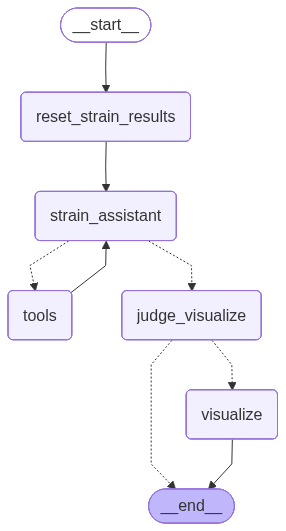

In [15]:

# =========================
# 11. 图
# =========================

tool_node = ToolNode([vector_method_g, cnn_method, bnn_method])

builder = StateGraph(MessagesState)

builder.add_node("reset_strain_results", reset_strain_results)
builder.add_node("strain_assistant", strain_assistant)
builder.add_node("tools", tool_node)
builder.add_node("judge_visualize", judge_visualize)
builder.add_node("visualize", visualize_node)

builder.add_edge(START, "reset_strain_results")
builder.add_edge("reset_strain_results", "strain_assistant")

builder.add_conditional_edges(
    "strain_assistant",
    route_after_assistant,
    {
        "tools": "tools",
        "judge_visualize": "judge_visualize",
    }
)

# 关键：工具执行完回到 assistant，让它继续思考是否还要调用
builder.add_edge("tools", "strain_assistant")

builder.add_conditional_edges(
    "judge_visualize",
    route_after_judge,
    {
        "visualize": "visualize",
        END: END,
    }
)

builder.add_edge("visualize", END)

strain_estimation = builder.compile()

# Show
display(Image(strain_estimation.get_graph(xray=True).draw_mermaid_png()))

In [16]:
# response = strain_eetimation.invoke(
#     {
#         "messages": [
#             HumanMessage(content="cnn,计算和矢量法应变计算，地址D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase1.mat,D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase2.mat。")
#         ]
#     },
#     config={"recursion_limit": 10}
# )

# response

In [18]:
from typing import TypedDict, Literal


class EntryGraphState(MessagesState):
    sub_agent:str

# task_assign tool
class TaskAssignment(TypedDict):
    """ Decision on what task type to execute """
    update_type: Literal['strain_estimation','chat']

# node
def supervisor(state: EntryGraphState):
    sys_msg = SystemMessage(
        content=(
            """
            你是一个任务执行助手，你需要根据用户的消息执行不同的任务\n
            可执行的任务类型：\n
            1. strain_estimation：可进行应变计算，具体计算方法包括矢量法，cnn,bnn\n
            2. chat：日常聊天\n
            以下是你用于分析用户消息的推理规则：\n
            1. 请仔细分析下方呈现的用户消息。\n
            2. 判断是否需要执行的任务：
                - 如果用户提到了应变计算，请调用 `TaskAssignment` 工具（参数 `type` 设为 `strain_estimation`）执行应变计算。
                - 如果用户没有提到应变计算，请调用 `TaskAssignment` 工具（参数 `type` 设为 `chat`）来正常对话。
             """ 
        )
    )
    response = llm.bind_tools([TaskAssignment]).invoke([sys_msg] + state["messages"])
    
    return {"sub_agent": "chat"} if "chat" in response.content.strip() else  {"sub_agent": "strain_estimation"}



# edge
def route_for_subagent(state: EntryGraphState) -> Literal['strain_estimation','chat',END]:
    """Reflect on the memories and chat history to decide whether to update the memory collection."""
    message = state['messages'][-1]
    if len(message.tool_calls) ==0:
        return END
    else:
        tool_call = message.tool_calls[0]
        if tool_call['args']['update_type'] == "strain_estimation":
            return "strain_estimation"
        elif tool_call['args']['update_type'] == "chat":
            return "chat"
        else:
            raise ValueError

    

In [19]:
# chat
def chat(state: MessagesState):
    messages=state["messages"]
    result = llm.invoke(messages)

    return {"messages": [result]}
 

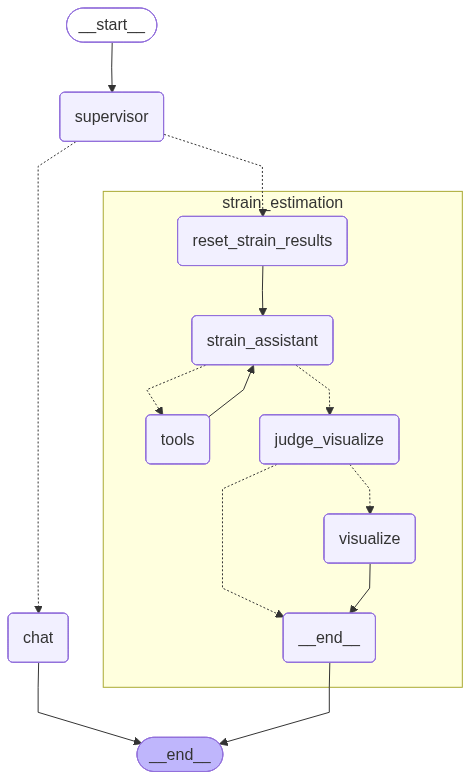

In [20]:
agent_builder = StateGraph(EntryGraphState)   

agent_builder.add_node("supervisor", supervisor)
agent_builder.add_node("chat", chat)
agent_builder.add_node("strain_estimation", builder.compile())

agent_builder.add_conditional_edges(
    "supervisor",
    route_for_subagent,
    {
        "strain_estimation": "strain_estimation",
        "chat": "chat",
    }
)
agent_builder.add_edge(START, "supervisor")
agent_builder.add_edge("chat", END)
agent_builder.add_edge("strain_estimation", END)

OCT_agent = agent_builder.compile()

# Show
display(Image(OCT_agent.get_graph(xray=True).draw_mermaid_png()))

In [21]:
response = OCT_agent.invoke(
    {
        "messages": [
            HumanMessage(content="cnn,计算和矢量法应变计算，地址D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase1.mat,D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase2.mat。")
        ]
    },
    config={"recursion_limit": 10}
)

response

AttributeError: 'HumanMessage' object has no attribute 'tool_calls'

In [41]:
response = OCT_agent.invoke(
    {
        "messages": [
            HumanMessage(content="推荐点好吃的")
        ]
    },
    config={"recursion_limit": 10}
)

response

{'messages': [HumanMessage(content='推荐点好吃的', additional_kwargs={}, response_metadata={}, id='bd5d7d5e-14b2-4444-8231-b995a979b58a'),
  AIMessage(content='<think>\n好的，用户让我推荐好吃的，我需要先考虑用户的具体需求。用户可能是在寻找餐厅推荐，或者想了解某种类型的美食，比如中餐、西餐，或者是甜点。也有可能用户对价格、地理位置或者饮食限制有特定要求。由于用户没有提供详细信息，我需要先询问清楚。\n\n首先，用户可能没有明确说明他们所在的城市或地区，不同地方的美食选择差异很大。比如北京有烤鸭，四川有火锅，广东有早茶。如果用户在国内，可能需要根据地区推荐；如果在国外，可能需要推荐当地受欢迎的中餐或融合菜。\n\n其次，用户的饮食偏好和禁忌也很重要。是否有素食需求？是否对辣度敏感？是否有过敏源？比如，如果用户是素食者，我需要推荐素食餐厅或菜品；如果不喜欢辣，可能需要避开川菜或湘菜。\n\n另外，预算也是一个关键因素。用户可能想要高档餐厅的精致料理，或者寻找性价比高的小吃。比如，人均消费高的餐厅可能适合特殊场合，而街头小吃则适合日常用餐。\n\n用户可能没有明确说明用餐场合，比如是朋友聚会、家庭聚餐还是独自用餐。不同的场合可能需要不同的推荐，比如朋友聚会适合火锅或烧烤，家庭聚餐适合适合多人分享的菜品。\n\n此外，用户可能对菜系有偏好，比如喜欢日料、韩餐、意大利菜等。如果用户没有说明，可能需要进一步询问，或者提供多样化的选择，涵盖不同菜系。\n\n考虑到用户可能没有提供足够的信息，我需要先询问他们所在的城市、预算、饮食偏好和用餐人数，以便给出更精准的推荐。同时，保持回复友好，让用户感到被重视，并愿意提供更多信息。\n\n最后，确保推荐内容多样化，包括不同菜系和价格区间，满足不同用户的需求。如果用户后续提供更多细节，可以进一步调整推荐内容。\n</think>\n\n好的！不过我需要先了解一些信息，才能给你更合适的推荐哦～  \n**请告诉我：**  \n1. **你所在的城市/地区**（不同地方的美食差异很大！）  \n2. **预算范围**（比如人均50元以内、100-200元等）  \n3. **饮食偏好**（比